# <i><b>This notebook is for Preliminarly Exploratory Data Analysis of the Fraud Data set...

## <b><i> Initial Numeric Exploratory Data Analysis of the fraud data

### <b> 1. Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as io
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
import math


### <b> 2. Load Data


In [2]:
# file path
excel_file_path = Path("C:/Users/HUSTLE/OneDrive/Documentos/panashe.dev/Projects/fraud-detection/data/fraud_dataset_raw.xlsx")

In [3]:
fraud_data = pd.read_excel(excel_file_path)

### <b> 3. Examining the top and bottom part of the fraud data

In [4]:
# First 5 rows
fraud_data.head()

,amount,browser,channel,customer_age,date,fraud,ip,isp,latitude,loginTime,...,onceoff_vs_beneficiary,os,paymentType,region,rtc_indicator,to_acc_volume,to_bank,txn_timestamp,uuid,transactor_id
0,120000.0,Chrome_Some(66),channel_B,51.0,2018-06-01,0,102.253.144.146,TelkomInternet,-29,2018-06-01T19:27:21.000Z,...,B,Windows_Some(7),F,ZA_null,0,18,FNBRMB,2018-06-01T19:46:21.000Z,NaN,9150237
1,1250.0,Chrome_Some(89),channel_B,26.0,2021-04-07,0,197.89.21.227,OPTINET,-26.3811,2021-04-07T16:10:10.000Z,...,B,Windows_Some(7),F,ZA_GP,0,21,FNBRMB,2021-04-07T16:13:39.000Z,NaN,13643308
2,200.0,Chrome_Some(75),channel_B,82.0,2019-07-31,0,169.0.104.125,AFRIHOSTOTHER,-26.3811,2019-07-31T14:31:35.000Z,...,B,Windows_Some(10),F,ZA_GP,0,6,FNBRMB,2019-07-31T14:41:47.000Z,NaN,74589
3,30.0,Chrome_Some(77),channel_B,37.0,2021-04-13,0,34.252.239.0,Amazoncom,53.3382,2021-04-13T21:12:38.000Z,...,O,Windows_Some(10),F,outside_ZA,0,421418,FNBRMB,2021-04-13T21:13:18.000Z,NaN,8776804
4,150.0,Chrome_Some(77),channel_B,32.0,2021-09-25,0,3.250.216.92,Amazoncom,53.3382,2021-09-25T21:05:45.000Z,...,O,Windows_Some(10),F,outside_ZA,0,160201,FNBRMB,2021-09-25T21:06:13.000Z,NaN,7653360


In [5]:
# Last 5 rows
fraud_data.tail()

,amount,browser,channel,customer_age,date,fraud,ip,isp,latitude,loginTime,...,onceoff_vs_beneficiary,os,paymentType,region,rtc_indicator,to_acc_volume,to_bank,txn_timestamp,uuid,transactor_id
53415,470.0,Chrome_Some(73),channel_B,45.0,2019-09-23,0,185.125.224.24,McAfee,-29,2019-09-23T18:43:52.000Z,...,B,Windows_Some(10),A,ZA_null,0,124866,ABSABank,2019-09-23T18:52:55.000Z,NaN,9634609
53416,1460.0,Chrome_Some(89),channel_B,89.0,2021-04-10,0,41.147.0.25,TelkomInternet,-34.0486,2021-04-10T11:39:37.000Z,...,B,Windows_Some(10),F,ZA_WC,0,26,FNBRMB,2021-04-10T11:40:21.000Z,NaN,4014583
53417,500.0,NaN,channel_B,49.0,2018-07-03,0,NaN,NaN,NaN,NaN,...,O,NaN,F,NaN,0,0,FNBRMB,2018-07-03T13:01:56.000Z,NaN,108771
53418,1000.0,Chrome_Some(37),channel_B,50.0,2021-07-23,1,93.113.125.26,truviewLLC,-25.8434,2021-07-23T04:49:13.000Z,...,O,Windows_Some(7),A,ZA_GP,0,3740,NedbankLimited,2021-07-23T04:53:47.000Z,NaN,5197543
53419,2400.0,Chrome_Some(70),channel_B,79.0,2018-11-29,0,105.227.154.164,TelkomInternet,-33.9672,2018-11-29T14:41:43.000Z,...,B,Windows_Some(10),F,ZA_EC,0,4,FNBRMB,2018-11-29T14:49:29.000Z,NaN,804611


### <b> 4. Examining the fraud data's dimensions

In [6]:
# Shape - Number of rows and columns
print("Number of rows:", fraud_data.shape[0])
print("Number of columns:", fraud_data.shape[1])

Number of rows: 53420
Number of columns: 24


### <b> 5. Examining the data's datatypes

In [7]:
data_types = fraud_data.dtypes.to_frame('data_types').reset_index()
data_types.columns = ["column", "data_type"]
data_types

,column,data_type
0,amount,float64
1,browser,object
2,channel,object
3,customer_age,float64
4,date,datetime64[ns]
5,fraud,int64
6,ip,object
7,isp,object
8,latitude,object
9,loginTime,object


### <b> 6. Examine the missing values in each column

In [8]:
# Number of missing values in each column
number_of_missing_values = fraud_data.isna().sum().to_frame("number_of_missing_values").reset_index()
number_of_missing_values.columns = ["column", "number_of_missing_values"]
number_of_missing_values

,column,number_of_missing_values
0,amount,0
1,browser,10207
2,channel,0
3,customer_age,263
4,date,0
5,fraud,0
6,ip,10207
7,isp,10207
8,latitude,10207
9,loginTime,10207


In [9]:
# percentage of missing values in each column
percentage_of_missing_values = round((fraud_data.isna().sum()*100)/(fraud_data.shape[0]),2).to_frame("percentage_of_missing_values").reset_index()
percentage_of_missing_values.columns = ["column","percentage_of_missing_values"]
percentage_of_missing_values

,column,percentage_of_missing_values
0,amount,0.00
1,browser,19.11
2,channel,0.00
3,customer_age,0.49
4,date,0.00
5,fraud,0.00
6,ip,19.11
7,isp,19.11
8,latitude,19.11
9,loginTime,19.11


### <b> 7. Examining the statistical properties of the data

#### <b> 7.1 Summary statistics of columns that are initially numerical columns

In [10]:
# Get all numerical columns from the data
numerical_columns = fraud_data.select_dtypes(["number"]).columns.to_list()
summary_statistics_of_numerical_variables = fraud_data[numerical_columns].describe()
summary_statistics_of_numerical_variables

,amount,customer_age,fraud,minute_of_day,rtc_indicator,to_acc_volume,uuid,transactor_id
count,5.342000e+04,53157.000000,53420.000000,53420.000000,53420.000000,5.342000e+04,0.0,5.342000e+04
mean,8.129677e+03,45.984687,0.064021,716.935923,0.040565,8.414774e+04,NaN,1.273563e+07
std,6.521779e+04,26.811421,0.244793,415.344481,0.197283,2.159379e+05,NaN,7.536294e+07
min,1.800000e-01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,NaN,1.736000e+03
25%,3.108925e+02,31.000000,0.000000,355.000000,0.000000,1.000000e+01,NaN,2.462684e+06
50%,1.100000e+03,48.000000,0.000000,717.000000,0.000000,1.040000e+02,NaN,5.191519e+06
75%,3.825000e+03,68.000000,0.000000,1074.000000,0.000000,2.621800e+04,NaN,9.951466e+06
max,8.000000e+06,99.000000,1.000000,1439.000000,1.000000,1.883463e+06,NaN,1.108927e+09


#### <b> 7.2 Summary statistics of columns that are non-numerical columns

In [11]:
# Get all numerical columns from the data
non_numerical_columns = fraud_data.select_dtypes(["object"]).columns.to_list()
summary_statistics_of_non_numerical_variables = fraud_data[non_numerical_columns].describe()
summary_statistics_of_non_numerical_variables

,browser,channel,ip,isp,latitude,loginTime,longitude,lut_first_paid_date,lut_last_paid_date,onceoff_vs_beneficiary,os,paymentType,region,to_bank,txn_timestamp
count,43213,53420,43213,43213,43213.0000,43213,43213.0000,40001,40001,53420,43213,53420,43213,47274,53420
unique,219,1,19215,400,504.0000,38131,502.0000,27979,37169,2,29,3,11,29,51919
top,Chrome_Some(77),channel_B,99.81.96.137,TelkomInternet,-26.3811,2021-02-25T08:52:52.000Z,27.8376,2021-07-03T19:54:33.000Z,2021-09-06T14:55:59.000Z,B,Windows_Some(10),A,ZA_GP,FNBRMB,2019-10-31T20:03:34.000Z
freq,4673,53420,589,8502,9601.0000,19,9601.0000,78,25,30290,27097,24670,18043,21999,5


#### <b> 7.2 Correlation statistics of numerical columns

In [12]:
# correlation statistics of numerical columns
correlation_statistics = fraud_data[numerical_columns].corr(method="pearson")
correlation_statistics

,amount,customer_age,fraud,minute_of_day,rtc_indicator,to_acc_volume,uuid,transactor_id
amount,1.000000,-0.031653,0.019849,-0.001505,0.003873,-0.041775,NaN,0.001117
customer_age,-0.031653,1.000000,0.139210,-0.001560,-0.071156,-0.054022,NaN,-0.698252
fraud,0.019849,0.139210,1.000000,-0.007569,0.121431,-0.084061,NaN,-0.026619
minute_of_day,-0.001505,-0.001560,-0.007569,1.000000,0.005457,-0.007946,NaN,0.004276
rtc_indicator,0.003873,-0.071156,0.121431,0.005457,1.000000,-0.077518,NaN,0.002181
to_acc_volume,-0.041775,-0.054022,-0.084061,-0.007946,-0.077518,1.000000,NaN,0.009027
uuid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transactor_id,0.001117,-0.698252,-0.026619,0.004276,0.002181,0.009027,NaN,1.000000


## <b><i> Initial Visual Exploratory Data Analysis

In [13]:
# Modern seaborn theme set
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

### <b> 1. Histograms for numerical data

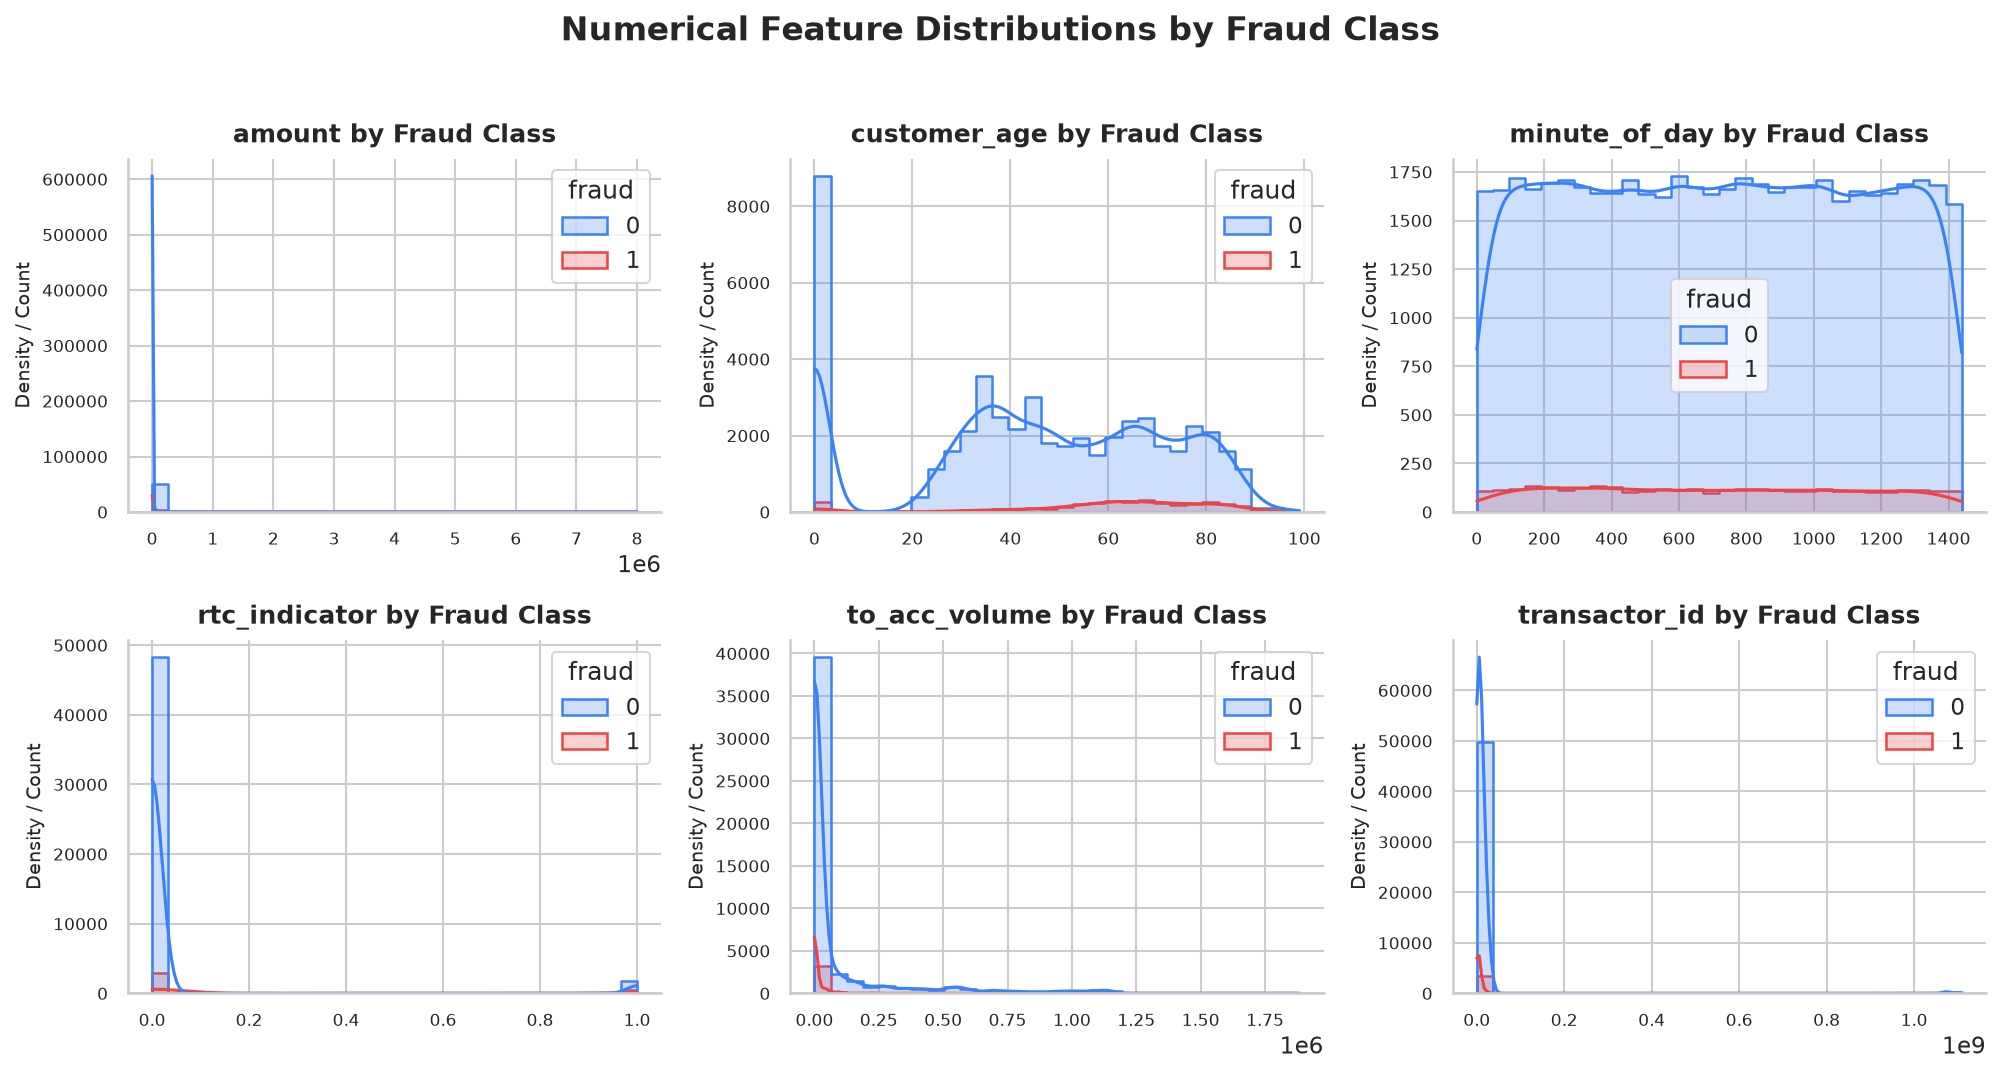

In [14]:
# Select numerical features, excluding target and single-value columns
num_cols = [
    c for c in fraud_data.select_dtypes(include=[np.number]).columns 
    if c != 'fraud' and fraud_data[c].nunique() > 1
]

# Define grid structure
n_cols = 3
n_vars = len(num_cols)
n_rows = math.ceil(n_vars / n_cols)

# Create figure and subplots
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(n_cols * 4.5, n_rows * 3.5)
)

# Flatten axes array for easy iteration
if n_vars == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Custom palette: Blue for Legitimate (0), Red for Fraud (1)
fraud_palette = {0: '#3B82F6', 1: '#EF4444'}

# PLOTTING LOOP
for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Check if both classes have enough unique points to calculate KDE curve safely
    can_fit_kde = True
    for val in fraud_data['fraud'].unique():
        subset = fraud_data[fraud_data['fraud'] == val][col].dropna()
        if len(subset) <= 1 or subset.nunique() <= 1:
            can_fit_kde = False
            break

    # Plot histogram with fraud class overlay
    sns.histplot(
        data=fraud_data,
        x=col,
        hue='fraud',
        kde=can_fit_kde,      # Dynamic KDE: turns off automatically if variance is 0
        ax=ax,
        palette=fraud_palette,
        element='step',        # Outlined steps
        common_norm=False,     # Normalizes each class independently
        bins=30,
        linewidth=1.2
    )
    
    # Style individual subplot
    ax.set_title(f'{col} by Fraud Class', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Density / Count', fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Despine
    sns.despine(ax=ax, top=True, right=True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Final Layout Adjustments
fig.suptitle('Numerical Feature Distributions by Fraud Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### <b>2. Donut Charts for categorical variables

In [15]:
# -------------------------------------------------------------------
# 1. FILTER COLUMNS WITH < 5 UNIQUE VALUES
# -------------------------------------------------------------------
# Select categorical/discrete numerical features with 2-4 unique values
cat_cols = [
    col for col in fraud_data.columns 
    if col != 'fraud' and 1 < fraud_data[col].nunique() < 5
]

n_vars = len(cat_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols) if n_vars > 0 else 1

if n_vars == 0:
    print("No categorical columns found with fewer than 5 unique values.")
else:
    # -------------------------------------------------------------------
    # 2. CREATE SUBPLOT GRID
    # -------------------------------------------------------------------
    fig = make_subplots(
        rows=n_rows, 
        cols=n_cols,
        specs=[[{'type': 'domain'}] * n_cols for _ in range(n_rows)],
        subplot_titles=[f'<b>{col}</b>' for col in cat_cols]
    )

    # Color palette
    colors = ['#3B82F6', '#EF4444', '#10B981', '#F59E0B', '#8B5CF6']

    # -------------------------------------------------------------------
    # 3. PLOTTING LOOP WITH FRAUD BREAKDOWN
    # -------------------------------------------------------------------
    for i, col in enumerate(cat_cols):
        row = (i // n_cols) + 1
        col_idx = (i % n_cols) + 1
        
        # Group by category to calculate total volume AND fraud count/rate
        grouped = fraud_data.groupby(col)['fraud'].agg(
            Total_Count='count',
            Fraud_Count='sum',
            Fraud_Rate='mean'
        ).reset_index()
        
        grouped['Fraud_Pct_Str'] = (grouped['Fraud_Rate'] * 100).map('{:.1f}%'.format)

        # Build custom hover text including fraud details
        hover_text = [
            f"Category: {val}<br>"
            f"Total Transactions: {tot:,}<br>"
            f"Fraud Cases: {frd:,}<br>"
            f"<b>Fraud Rate: {pct}</b>"
            for val, tot, frd, pct in zip(
                grouped[col], 
                grouped['Total_Count'], 
                grouped['Fraud_Count'], 
                grouped['Fraud_Pct_Str']
            )
        ]

        # Add Donut Chart trace
        fig.add_trace(
            go.Pie(
                labels=grouped[col].astype(str),
                values=grouped['Total_Count'],
                hole=0.55,  # Donut hole size
                marker=dict(colors=colors, line=dict(color='#FFFFFF', width=2)),
                textinfo='label+percent',
                hoverinfo='text',
                hovertext=hover_text,
                showlegend=False
            ),
            row=row, 
            col=col_idx
        )

    # -------------------------------------------------------------------
    # 4. STYLING & LAYOUT ADJUSTMENTS
    # -------------------------------------------------------------------
    fig.update_layout(
        title_text="<b>Low-Cardinality Features (< 5 Categories) with Fraud Breakdown</b>",
        title_font=dict(size=16, family="Arial"),
        height=350 * n_rows,
        width=1000,
        template='plotly_white',
        margin=dict(t=80, b=40, l=40, r=40)
    )

    # Explicit renderer fall-back if notebook MIME type gives issues
    try:
        fig.show()
    except ValueError:
        fig.show(renderer="iframe")

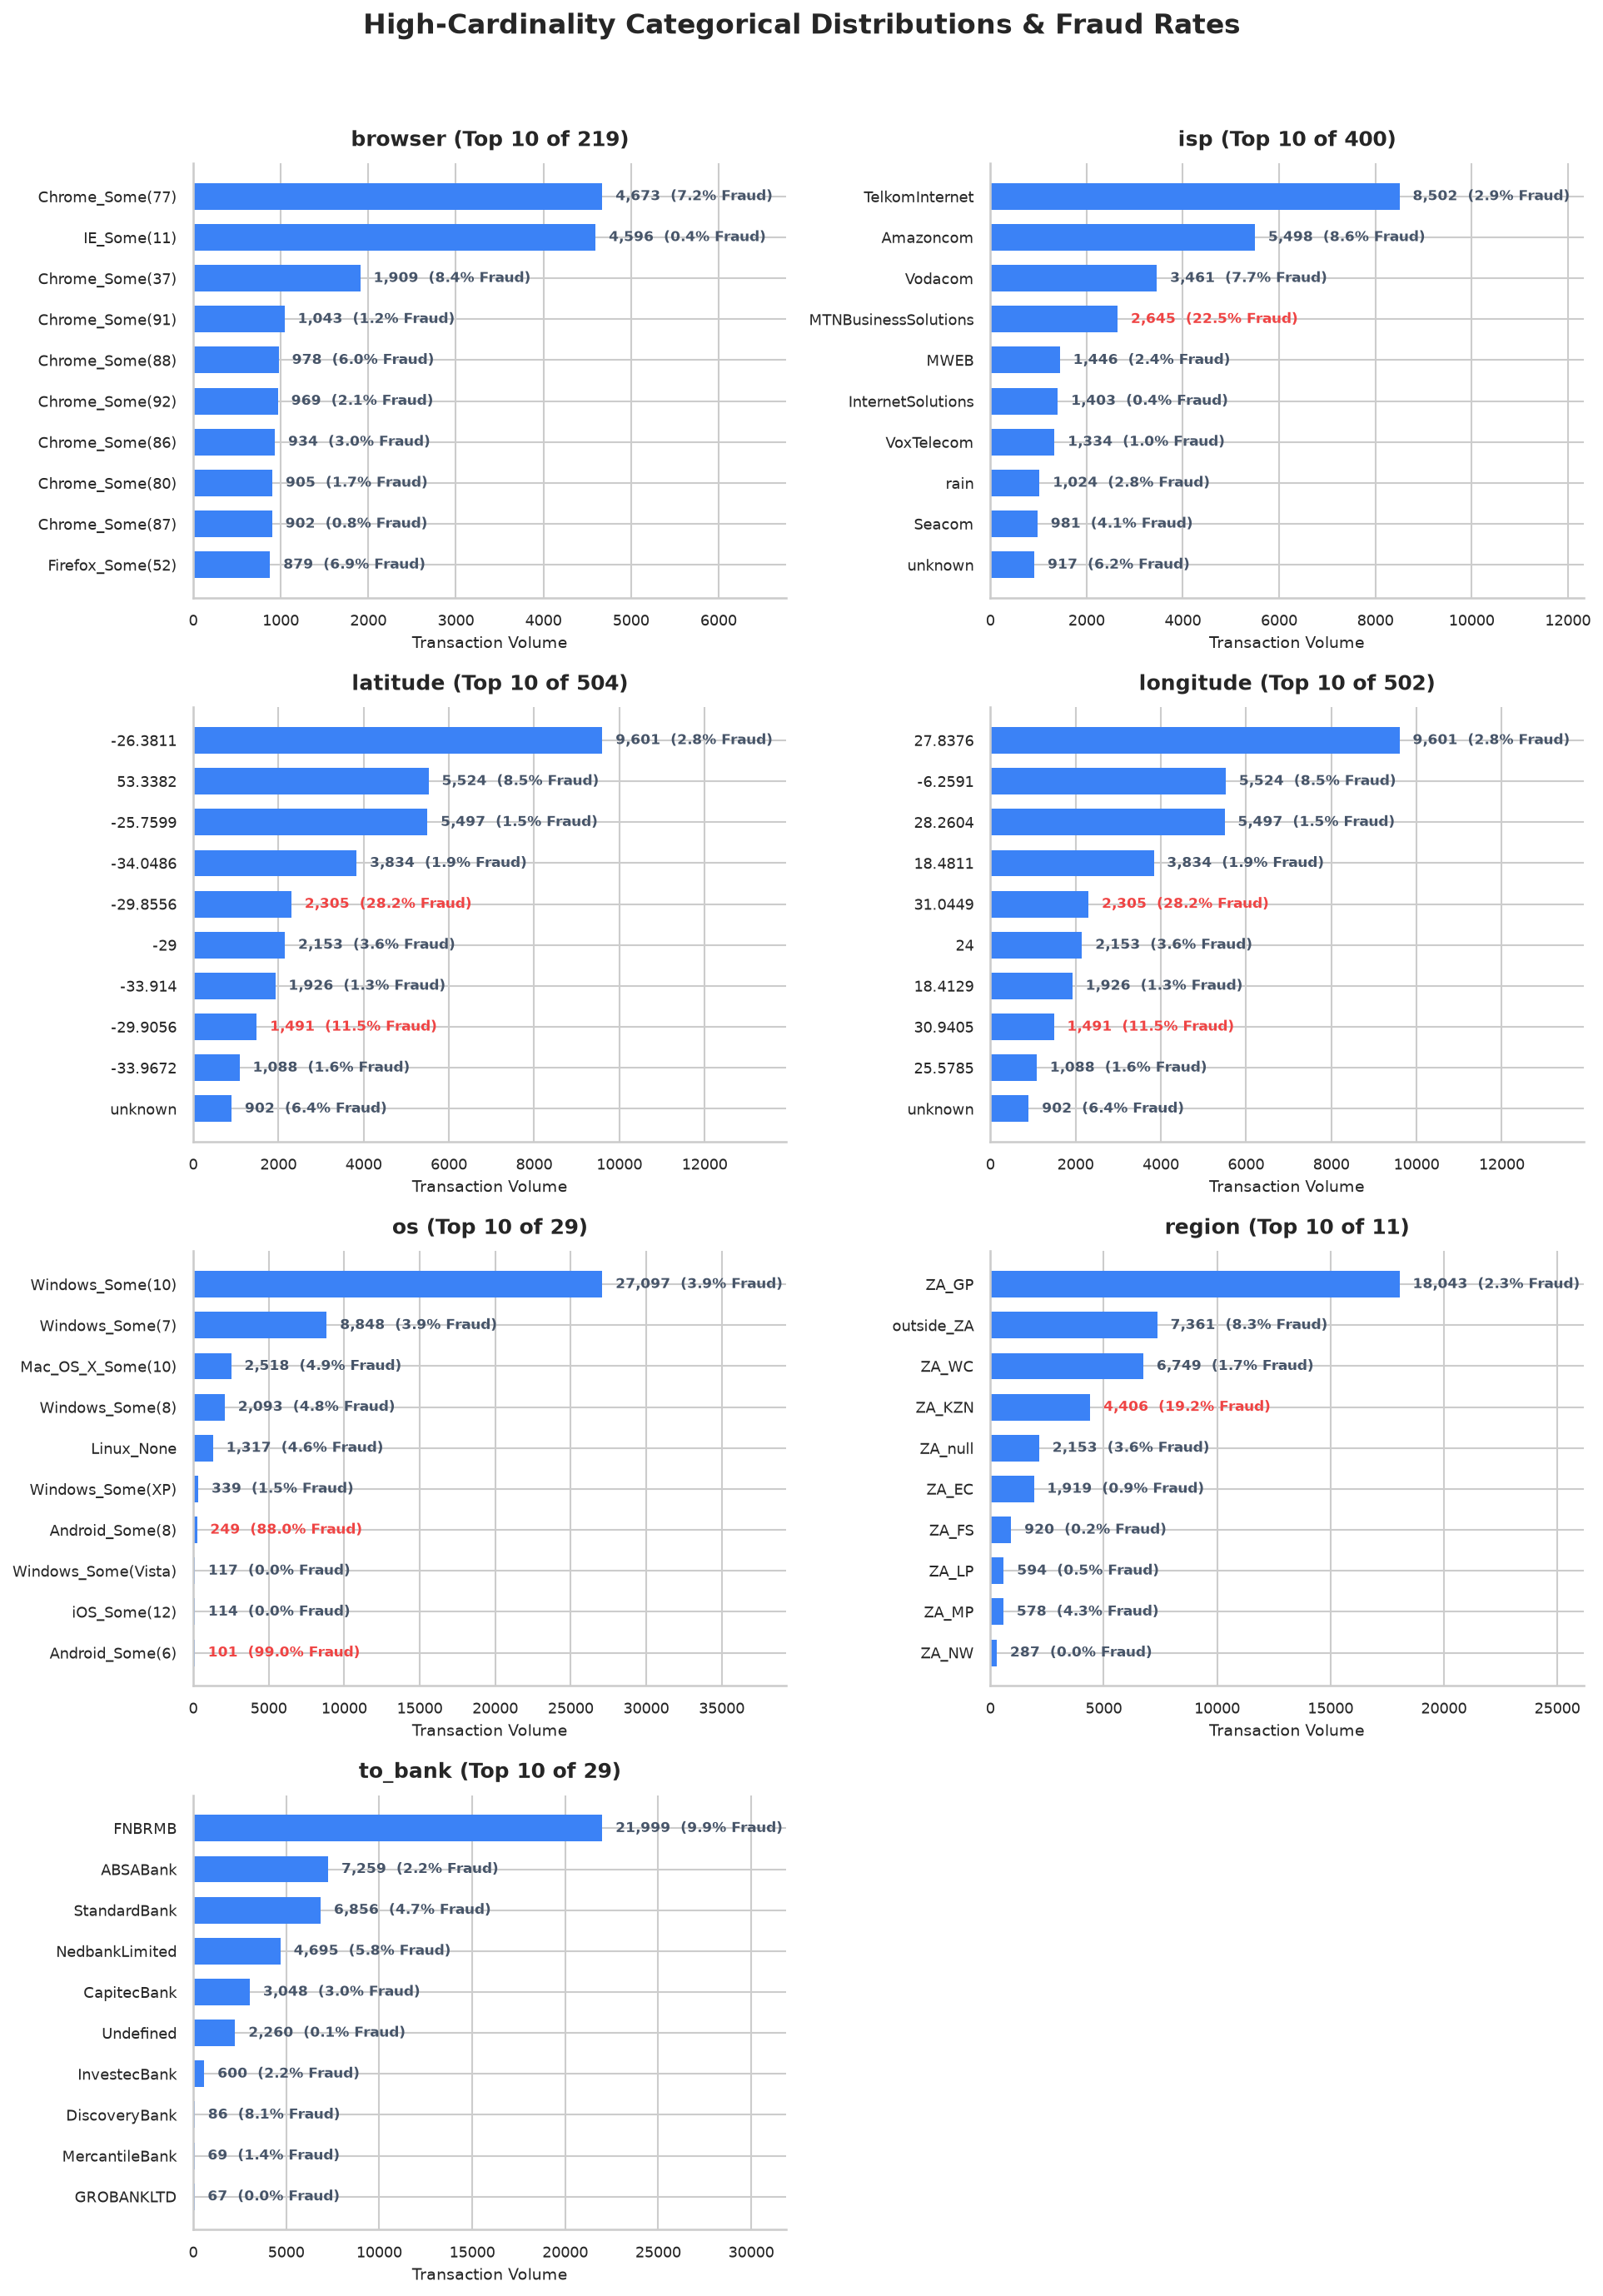

In [16]:
# Set clean modern theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. FILTER CATEGORICAL COLUMNS WITH nunique >= 5
# -------------------------------------------------------------------
# Find object/category columns (or discrete numeric categories) with >= 5 unique values
# Excluding target 'fraud' and high-cardinality unique IDs (e.g., transaction ID > 1000 unique)
cat_cols_high = [
    col for col in fraud_data.select_dtypes(include=['object', 'category', 'string']).columns 
    if col != 'fraud' and 5 <= fraud_data[col].nunique() <= 1000
]

# If non-numeric categorical data wasn't explicitly cast to 'object', check all non-fraud columns:
if len(cat_cols_high) == 0:
    cat_cols_high = [
        col for col in fraud_data.columns 
        if col != 'fraud' and 5 <= fraud_data[col].nunique() <= 50
    ]

n_vars = len(cat_cols_high)
TOP_N = 10  # Limit to top N categories per feature to maintain clean visuals

if n_vars == 0:
    print("No categorical columns found with 5 or more unique values.")
else:
    # Grid setup
    n_cols = 2  # 2 columns per row works best for horizontal bar charts
    n_rows = math.ceil(n_vars / n_cols)

    fig, axes = plt.subplots(
        nrows=n_rows, 
        ncols=n_cols, 
        figsize=(n_cols * 6.5, n_rows * 4.5)
    )

    # Flatten axes array for easy iteration
    if n_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # -------------------------------------------------------------------
    # 2. PLOTTING LOOP
    # -------------------------------------------------------------------
    for i, col in enumerate(cat_cols_high):
        ax = axes[i]
        
        # Get top N most frequent categories for this column
        top_categories = fraud_data[col].value_counts().head(TOP_N).index
        subset = fraud_data[fraud_data[col].isin(top_categories)]
        
        # Calculate Volume Count and Fraud Rate per top category
        stats = subset.groupby(col).agg(
            Total=('fraud', 'count'),
            Fraud_Rate=('fraud', 'mean')
        ).reset_index()
        
        # Sort by total volume descending
        stats = stats.sort_values(by='Total', ascending=True) # Ascending for horizontal top-down look
        
        # Plot Horizontal Bars
        bars = ax.barh(
            y=stats[col].astype(str), 
            width=stats['Total'], 
            color='#3B82F6', 
            edgecolor='none', 
            height=0.65
        )
        
        # Annotate bars with Total Count and Fraud Rate %
        max_width = stats['Total'].max()
        for bar, f_rate in zip(bars, stats['Fraud_Rate']):
            width = bar.get_width()
            fraud_pct = f_rate * 100
            
            # Format annotation string
            label_text = f" {int(width):,}  ({fraud_pct:.1f}% Fraud)"
            
            # Color text red if fraud rate is above 10%
            text_color = '#EF4444' if fraud_pct >= 10 else '#475569'
            
            ax.text(
                x=width + (max_width * 0.02), 
                y=bar.get_y() + bar.get_height() / 2, 
                s=label_text, 
                va='center', 
                ha='left', 
                fontsize=8, 
                fontweight='bold',
                color=text_color
            )

        # Style individual subplot
        total_unique = fraud_data[col].nunique()
        title_suffix = f" (Top {TOP_N} of {total_unique})" if total_unique > TOP_N else ""
        ax.set_title(f'{col}{title_suffix}', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Transaction Volume', fontsize=9)
        ax.set_ylabel('')
        ax.tick_params(axis='both', which='major', labelsize=8.5)
        ax.set_xlim(0, max_width * 1.45)  # Leave room on the right for text annotations
        
        # Despine border
        sns.despine(ax=ax, top=True, right=True)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Final Layout Adjustments
    fig.suptitle('High-Cardinality Categorical Distributions & Fraud Rates', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()